In [2]:
import shap
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Load final model and test data for SHAP explainability

model = joblib.load("../models/xgb_final_model.pkl")
feature_names = pd.read_csv("../data/processed/feature_names.csv").iloc[:, 0].tolist()

X_test = np.load("../data/processed/X_test.npy")
y_test = np.load("../data/processed/y_test.npy")

# Convert to dataframe with feature names
X_test_df = pd.DataFrame(X_test, columns=feature_names)

print(X_test_df.shape)

(1407, 26)


In [4]:
# Compute SHAP values using TreeExplainer (optimized for tree-based models)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_df)

print(f"SHAP values shape: {shap_values.shape}")

SHAP values shape: (1407, 26)


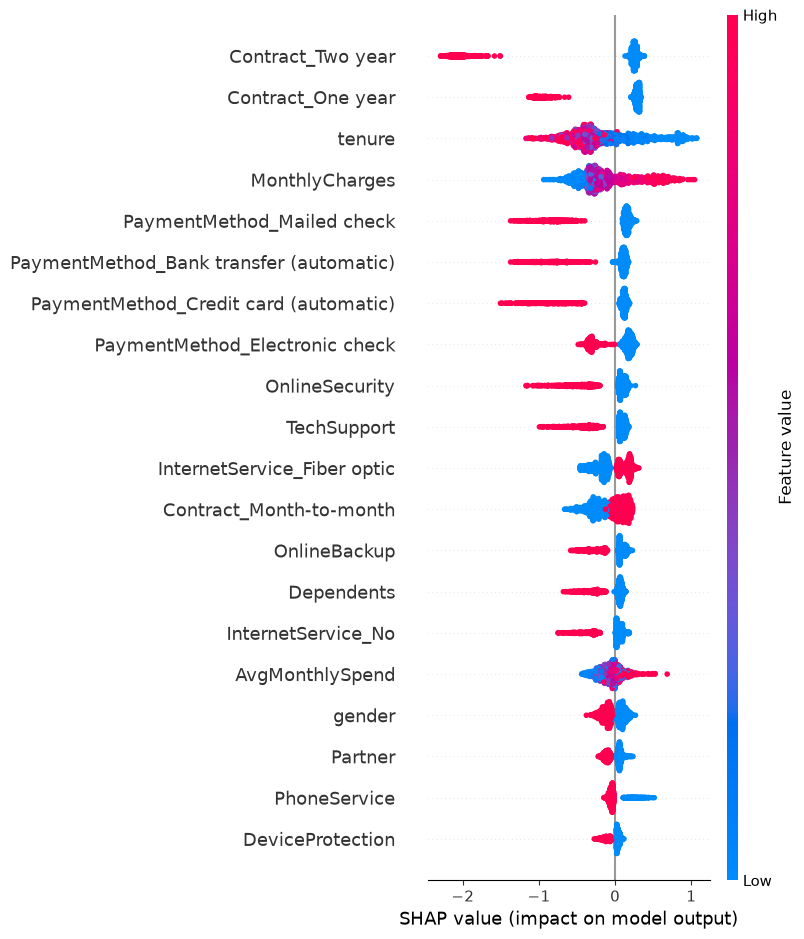

In [5]:
# SHAP summary plot - global feature importance
# Each dot is a customer, color shows feature value (red=high, blue=low)
# Position on x-axis shows impact on churn prediction

shap.summary_plot(shap_values, X_test_df, plot_type="dot", show=True)

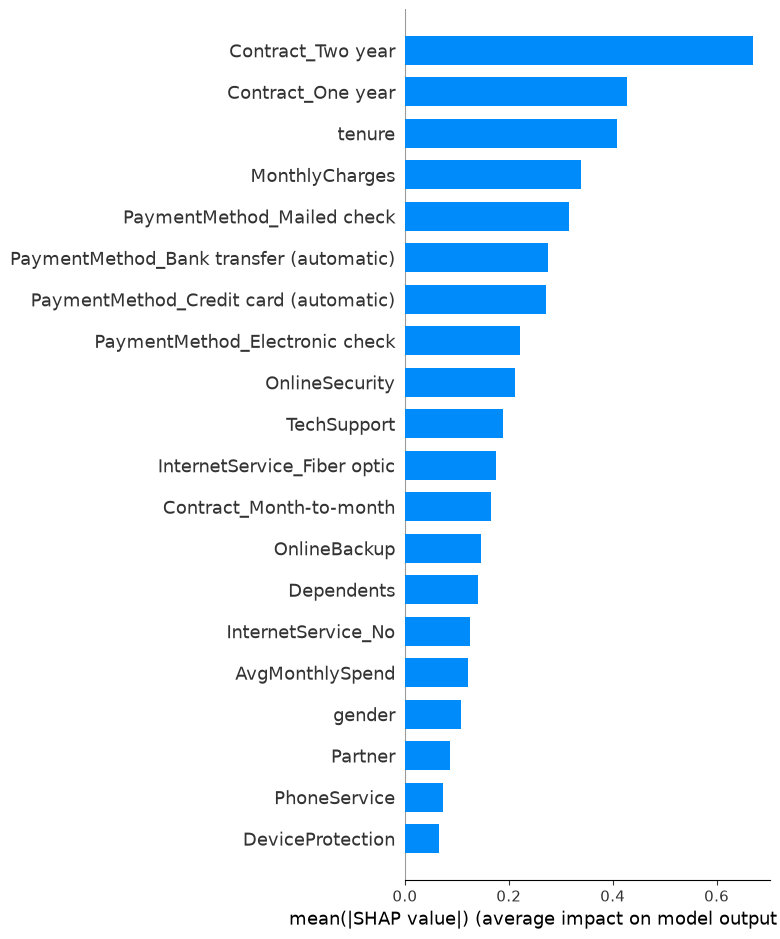

In [6]:
# SHAP bar plot - mean absolute SHAP values
# Clean version showing overall feature importance ranking

shap.summary_plot(shap_values, X_test_df, plot_type="bar", show=True)

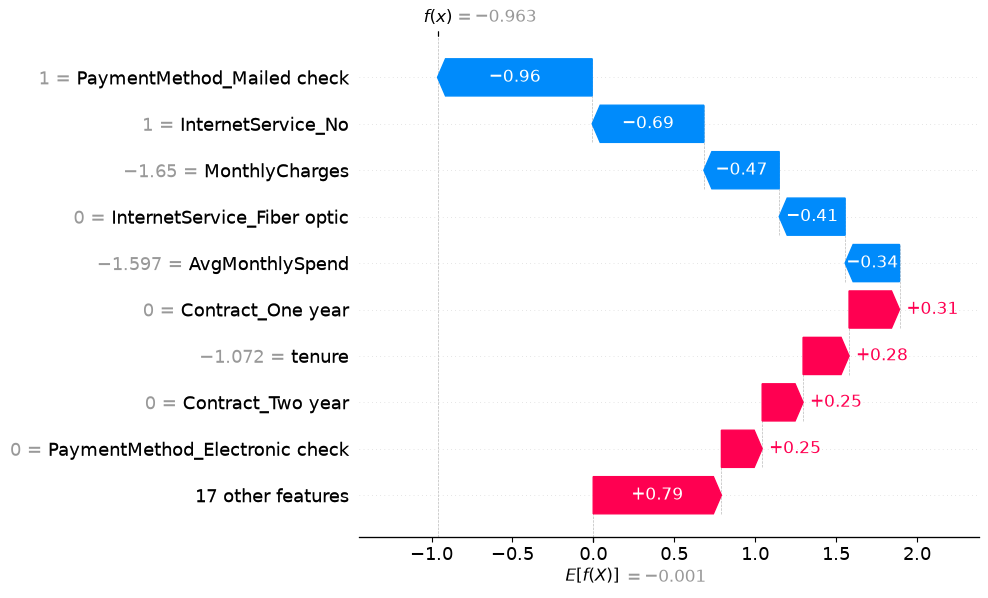

In [7]:
# SHAP waterfall plot for a single churned customer
# Shows exactly which features pushed this customer toward churn prediction

churned_idx = np.where(y_test == 1)[0][0]  # first actual churner in test set

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[churned_idx],
        base_values=explainer.expected_value,
        data=X_test_df.iloc[churned_idx],
        feature_names=feature_names
    )
)